In [4]:
import os

print(os.path.abspath(os.curdir))

d:\Data Kuliah\Semester 9\Data in Brief\dataset\notebooks


In [5]:
import os
os.chdir("..")

In [6]:
print(os.path.abspath(os.curdir))

d:\Data Kuliah\Semester 9\Data in Brief\dataset


In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles, venn2
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import itertools

def extract_ngrams(texts, n_range=(2, 3), min_freq=2):
    """
    Extract n-grams from texts with minimum frequency threshold.
    
    Parameters:
    - texts: list of text strings
    - n_range: tuple of (min_n, max_n) for n-gram range
    - min_freq: minimum frequency for an n-gram to be included
    """
    vectorizer = CountVectorizer(
        ngram_range=n_range,
        min_df=min_freq,
        lowercase=True,
        token_pattern=r'\b\w+\b'
    )
    
    try:
        X = vectorizer.fit_transform(texts)
        ngrams = vectorizer.get_feature_names_out()
        frequencies = np.asarray(X.sum(axis=0)).flatten()
        return set(ngrams), dict(zip(ngrams, frequencies))
    except:
        return set(), {}

def create_4way_venn_diagram(data_path, output_path='venn_diagram.png', 
                             n_range=(2, 3), min_freq=2, top_n=20, 
                             figsize=(16, 10), dpi=300):
    """
    Create a 4-way Venn diagram for overlapping n-grams across 4 classes.
    
    Parameters:
    - data_path: path to CSV file with 'message' and 'label' columns
    - output_path: path to save the output image
    - n_range: tuple of (min_n, max_n) for n-gram range
    - min_freq: minimum frequency for n-gram inclusion
    - top_n: number of top n-grams to consider per class
    - figsize: figure size
    - dpi: image resolution
    """
    
    # Load data
    train_df = pd.read_csv(os.path.join(data_path, 'filtered_train.csv'))
    test_df = pd.read_csv(os.path.join(data_path, 'filtered_test.csv'))
    df = pd.concat([train_df, test_df], ignore_index=True)
    
    # Get unique labels (should be: Normal, Low, Medium, High)
    labels = df['label'].unique()
    if len(labels) != 4:
        print(f"Warning: Expected 4 classes, found {len(labels)}: {labels}")
    
    # Extract n-grams for each class
    class_ngrams = {}
    class_ngram_freq = {}
    
    for label in labels:
        texts = df[df['label'] == label]['message'].tolist()
        ngrams, freq = extract_ngrams(texts, n_range=n_range, min_freq=min_freq)
        
        # Keep only top_n most frequent n-grams per class
        if freq:
            top_ngrams = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
            class_ngrams[label] = set([ng for ng, _ in top_ngrams])
            class_ngram_freq[label] = dict(top_ngrams)
        else:
            class_ngrams[label] = set()
            class_ngram_freq[label] = {}
        
        print(f"{label}: {len(class_ngrams[label])} n-grams")
    
    # For 4-way Venn, we'll create a 2x2 subplot layout with 3-way Venn diagrams
    # showing different combinations
    fig = plt.figure(figsize=figsize)
    
    # Convert labels to list for consistent ordering
    label_list = list(labels)
    
    # Create 4 subplots for different 3-way combinations
    combinations = [
        (0, 1, 2),  # First 3 classes
        (0, 1, 3),  # Different combination
        (0, 2, 3),  # Different combination
        (1, 2, 3),  # Last 3 classes
    ]
    
    for idx, combo in enumerate(combinations):
        ax = plt.subplot(2, 2, idx + 1)
        
        selected_labels = [label_list[i] for i in combo]
        sets = [class_ngrams[label] for label in selected_labels]
        
        # Create 3-way Venn diagram
        v = venn3(sets, set_labels=selected_labels, ax=ax, alpha=0.6)
        venn3_circles(sets, ax=ax, linewidth=1.5)
        
        # Customize colors
        colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
        if v:
            for i, color in enumerate([colors[combo[0]], colors[combo[1]], colors[combo[2]]]):
                if v.get_patch_by_id(f'10{"0" if i==0 else ""}{"0" if i==1 else ""}{"0" if i==2 else ""}'):
                    patch_id = ['100', '010', '001'][i]
                    patch = v.get_patch_by_id(patch_id)
                    if patch:
                        patch.set_color(color)
        
        ax.set_title(f"N-gram Overlap: {' vs '.join(selected_labels)}", 
                    fontsize=12, fontweight='bold')
    
    plt.suptitle(f'Overlapping N-gram Phrases Across Classes\n(n-gram range: {n_range}, min frequency: {min_freq}, top {top_n} per class)', 
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save figure
    plt.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"\nVenn diagram saved to: {output_path}")
    
    # Print overlap statistics
    print("\n=== Overlap Statistics ===")
    
    # Calculate all possible intersections
    for r in range(2, 5):
        for combo in itertools.combinations(label_list, r):
            intersection = set.intersection(*[class_ngrams[label] for label in combo])
            if intersection:
                print(f"\n{' ∩ '.join(combo)}: {len(intersection)} phrases")
                if len(intersection) <= 10:  # Print if not too many
                    for phrase in sorted(intersection):
                        print(f"  - {phrase}")
    
    return class_ngrams, class_ngram_freq

Low: 30 n-grams
High: 30 n-grams
Normal: 30 n-grams
Medium: 30 n-grams

Venn diagram saved to: ngram_venn_diagram.png

=== Overlap Statistics ===

Low ∩ High: 4 phrases
  - aircraft is
  - contact dji
  - contact dji support
  - dji support

Low ∩ Normal: 2 phrases
  - aircraft is
  - obstacle avoidance

Low ∩ Medium: 5 phrases
  - aircraft is
  - fly with
  - fly with caution
  - the aircraft
  - with caution

High ∩ Normal: 3 phrases
  - aircraft is
  - return to
  - to home

High ∩ Medium: 4 phrases
  - aircraft is
  - return to
  - to home
  - unable to

Normal ∩ Medium: 5 phrases
  - aircraft is
  - remote controller
  - return to
  - return to home
  - to home

Low ∩ High ∩ Normal: 1 phrases
  - aircraft is

Low ∩ High ∩ Medium: 1 phrases
  - aircraft is

Low ∩ Normal ∩ Medium: 1 phrases
  - aircraft is

High ∩ Normal ∩ Medium: 3 phrases
  - aircraft is
  - return to
  - to home

Low ∩ High ∩ Normal ∩ Medium: 1 phrases
  - aircraft is


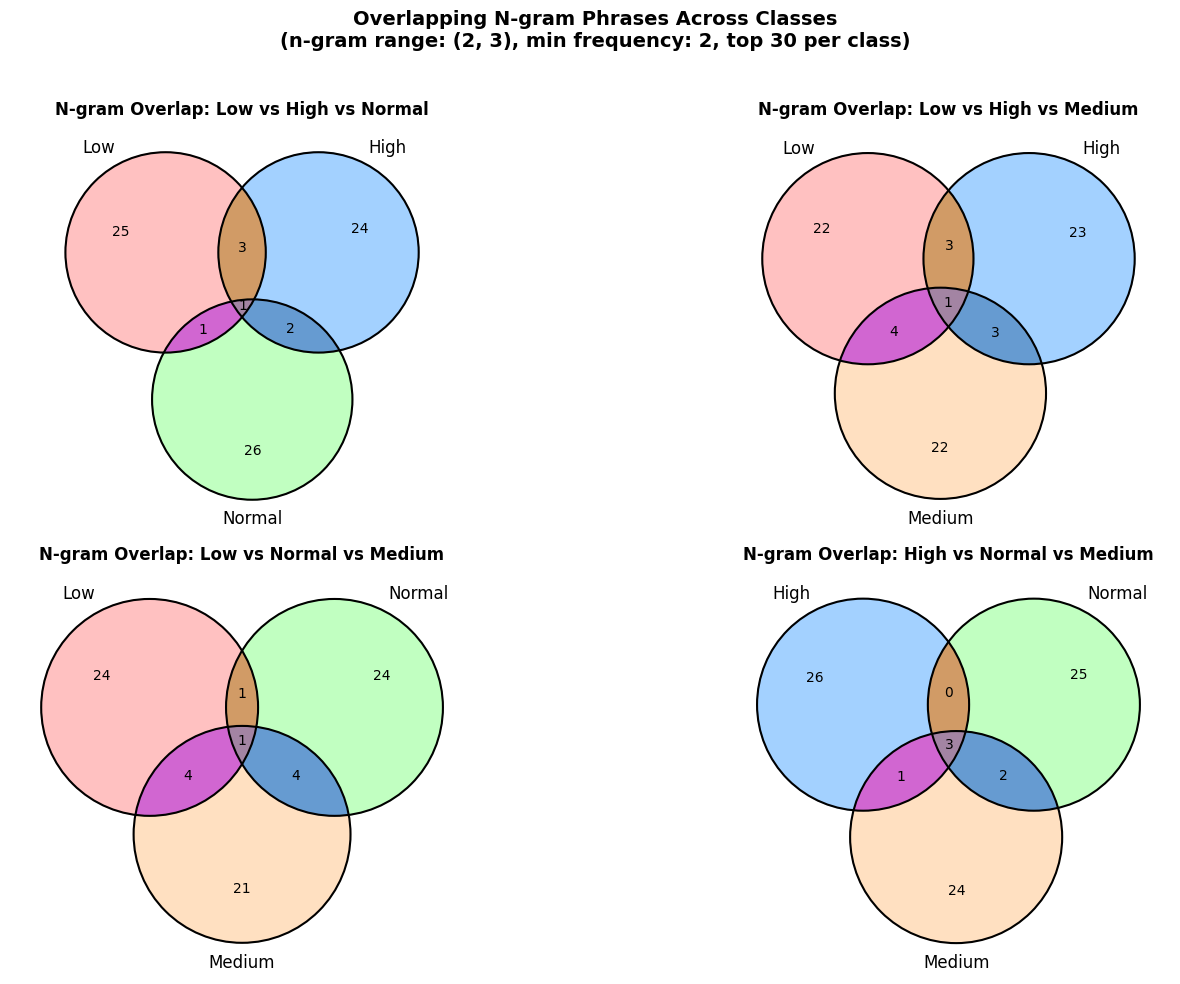

In [9]:
# Usage example
# if __name__ == "__main__":
# Adjust these parameters as needed
data_path = os.path.join('severity', 'unique')  # Change to your CSV file path
output_path = 'ngram_venn_diagram.png'

# Parameters
n_range = (2, 3)  # Extract 2-grams and 3-grams
min_freq = 2      # Minimum frequency for n-gram to be included
top_n = 30        # Top N n-grams per class to consider

class_ngrams, class_freq = create_4way_venn_diagram(
    data_path=data_path,
    output_path=output_path,
    n_range=n_range,
    min_freq=min_freq,
    top_n=top_n,
    figsize=(16, 10),
    dpi=300
)

plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import itertools

def extract_ngrams(texts, n_range=(2, 3), min_freq=2):
    """
    Extract n-grams from texts with minimum frequency threshold.
    
    Parameters:
    - texts: list of text strings
    - n_range: tuple of (min_n, max_n) for n-gram range
    - min_freq: minimum frequency for an n-gram to be included
    """
    vectorizer = CountVectorizer(
        ngram_range=n_range,
        min_df=min_freq,
        lowercase=True,
        token_pattern=r'\b\w+\b'
    )
    
    try:
        X = vectorizer.fit_transform(texts)
        ngrams = vectorizer.get_feature_names_out()
        frequencies = np.asarray(X.sum(axis=0)).flatten()
        return set(ngrams), dict(zip(ngrams, frequencies))
    except:
        return set(), {}

def get_representative_phrases(phrases, freq_dict, max_phrases=3):
    """
    Get representative phrases sorted by frequency.
    
    Parameters:
    - phrases: set of phrases
    - freq_dict: dictionary mapping phrases to frequencies
    - max_phrases: maximum number of phrases to return
    """
    if not phrases:
        return []
    
    # Sort by frequency (sum across all classes that have this phrase)
    sorted_phrases = sorted(phrases, key=lambda x: sum([freq_dict.get(label, {}).get(x, 0) 
                                                         for label in freq_dict.keys()]), 
                           reverse=True)
    return sorted_phrases[:max_phrases]

def create_venn_with_phrases(data_path, output_path='venn_diagram_with_phrases.png', 
                            n_range=(2, 3), min_freq=3, top_n=50, 
                            max_phrases_per_region=3, figsize=(18, 12), dpi=300):
    """
    Create a 4-way Venn diagram showing representative overlapping n-grams.
    
    Parameters:
    - data_path: path to CSV file with 'message' and 'label' columns
    - output_path: path to save the output image
    - n_range: tuple of (min_n, max_n) for n-gram range
    - min_freq: minimum frequency for n-gram inclusion
    - top_n: number of top n-grams to consider per class
    - max_phrases_per_region: max phrases to show in each Venn region
    - figsize: figure size
    - dpi: image resolution
    """
    
    # Load data
    train_df = pd.read_csv(os.path.join(data_path, 'filtered_train.csv'))
    test_df = pd.read_csv(os.path.join(data_path, 'filtered_test.csv'))
    df = pd.concat([train_df, test_df], ignore_index=True)
    
    # Get unique labels
    labels = sorted(df['label'].unique())
    if len(labels) != 4:
        print(f"Warning: Expected 4 classes, found {len(labels)}: {labels}")
    
    # Extract n-grams for each class
    class_ngrams = {}
    class_ngram_freq = {}
    
    for label in labels:
        texts = df[df['label'] == label]['message'].tolist()
        ngrams, freq = extract_ngrams(texts, n_range=n_range, min_freq=min_freq)
        
        # Keep only top_n most frequent n-grams per class
        if freq:
            top_ngrams = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
            class_ngrams[label] = set([ng for ng, _ in top_ngrams])
            class_ngram_freq[label] = dict(top_ngrams)
        else:
            class_ngrams[label] = set()
            class_ngram_freq[label] = {}
        
        print(f"{label}: {len(class_ngrams[label])} n-grams")
    
    # Create figure with 4 subplots for different 3-way combinations
    fig = plt.figure(figsize=figsize)
    
    label_list = list(labels)
    
    # Define 4 different 3-way combinations
    combinations = [
        (0, 1, 2),  
        (0, 1, 3),  
        (0, 2, 3),  
        (1, 2, 3),  
    ]
    
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    
    for idx, combo in enumerate(combinations):
        ax = plt.subplot(2, 2, idx + 1)
        
        selected_labels = [label_list[i] for i in combo]
        sets = [class_ngrams[label] for label in selected_labels]
        
        # Create 3-way Venn diagram
        v = venn3(sets, set_labels=selected_labels, ax=ax, alpha=0.5)
        venn3_circles(sets, ax=ax, linewidth=2)
        
        # Customize colors for individual sets
        if v:
            patch_ids = ['100', '010', '001']
            for i, patch_id in enumerate(patch_ids):
                patch = v.get_patch_by_id(patch_id)
                if patch:
                    patch.set_color(colors[combo[i]])
                    patch.set_alpha(0.5)
        
        # Calculate intersections and add phrases as text
        set_dict = {
            '100': sets[0] - sets[1] - sets[2],
            '010': sets[1] - sets[0] - sets[2],
            '001': sets[2] - sets[0] - sets[1],
            '110': (sets[0] & sets[1]) - sets[2],
            '101': (sets[0] & sets[2]) - sets[1],
            '011': (sets[1] & sets[2]) - sets[0],
            '111': sets[0] & sets[1] & sets[2]
        }
        
        # Add representative phrases to each region
        for region_id, phrases in set_dict.items():
            if phrases and v.get_label_by_id(region_id):
                # Get representative phrases
                repr_phrases = get_representative_phrases(
                    phrases, class_ngram_freq, max_phrases_per_region
                )
                
                # Format text
                if repr_phrases:
                    text = '\n'.join([f'"{p}"' for p in repr_phrases])
                    
                    # Get the label object and update it
                    label_obj = v.get_label_by_id(region_id)
                    
                    # Show count and phrases
                    count_text = f"n={len(phrases)}\n{text}"
                    label_obj.set_text(count_text)
                    label_obj.set_fontsize(8)
                    label_obj.set_fontstyle('italic')
        
        ax.set_title(f"{' ∩ '.join(selected_labels)}", 
                    fontsize=11, fontweight='bold', pad=10)
    
    plt.suptitle(f'Overlapping N-gram Phrases Demonstrating Classification Challenges\n' + 
                 f'(n-gram range: {n_range}, min frequency: {min_freq}, showing top {max_phrases_per_region} phrases per region)', 
                 fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save figure
    plt.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"\nVenn diagram saved to: {output_path}")
    
    # Print detailed overlap statistics
    print("\n=== Representative Overlapping Phrases ===")
    
    for r in range(2, 5):
        for combo in itertools.combinations(label_list, r):
            intersection = set.intersection(*[class_ngrams[label] for label in combo])
            if intersection:
                repr_phrases = get_representative_phrases(intersection, class_ngram_freq, 5)
                print(f"\n{' ∩ '.join(combo)} ({len(intersection)} total):")
                for phrase in repr_phrases:
                    freqs = [class_ngram_freq.get(label, {}).get(phrase, 0) for label in combo]
                    print(f"  - \"{phrase}\" (freq: {freqs})")
    
    return class_ngrams, class_ngram_freq

High: 13 n-grams
Low: 50 n-grams
Medium: 50 n-grams
Normal: 50 n-grams

Venn diagram saved to: venn_diagram_with_phrases.png

=== Representative Overlapping Phrases ===

High ∩ Low (4 total):
  - "aircraft is" (freq: [np.int64(6), np.int64(11)])
  - "dji support" (freq: [np.int64(4), np.int64(15)])
  - "contact dji support" (freq: [np.int64(4), np.int64(15)])
  - "contact dji" (freq: [np.int64(4), np.int64(15)])

High ∩ Medium (4 total):
  - "aircraft is" (freq: [np.int64(6), np.int64(5)])
  - "to home" (freq: [np.int64(4), np.int64(17)])
  - "return to" (freq: [np.int64(3), np.int64(15)])
  - "unable to" (freq: [np.int64(4), np.int64(8)])

High ∩ Normal (3 total):
  - "aircraft is" (freq: [np.int64(6), np.int64(19)])
  - "to home" (freq: [np.int64(4), np.int64(12)])
  - "return to" (freq: [np.int64(3), np.int64(10)])

Low ∩ Medium (7 total):
  - "with caution" (freq: [np.int64(42), np.int64(20)])
  - "fly with" (freq: [np.int64(40), np.int64(20)])
  - "fly with caution" (freq: [np.int

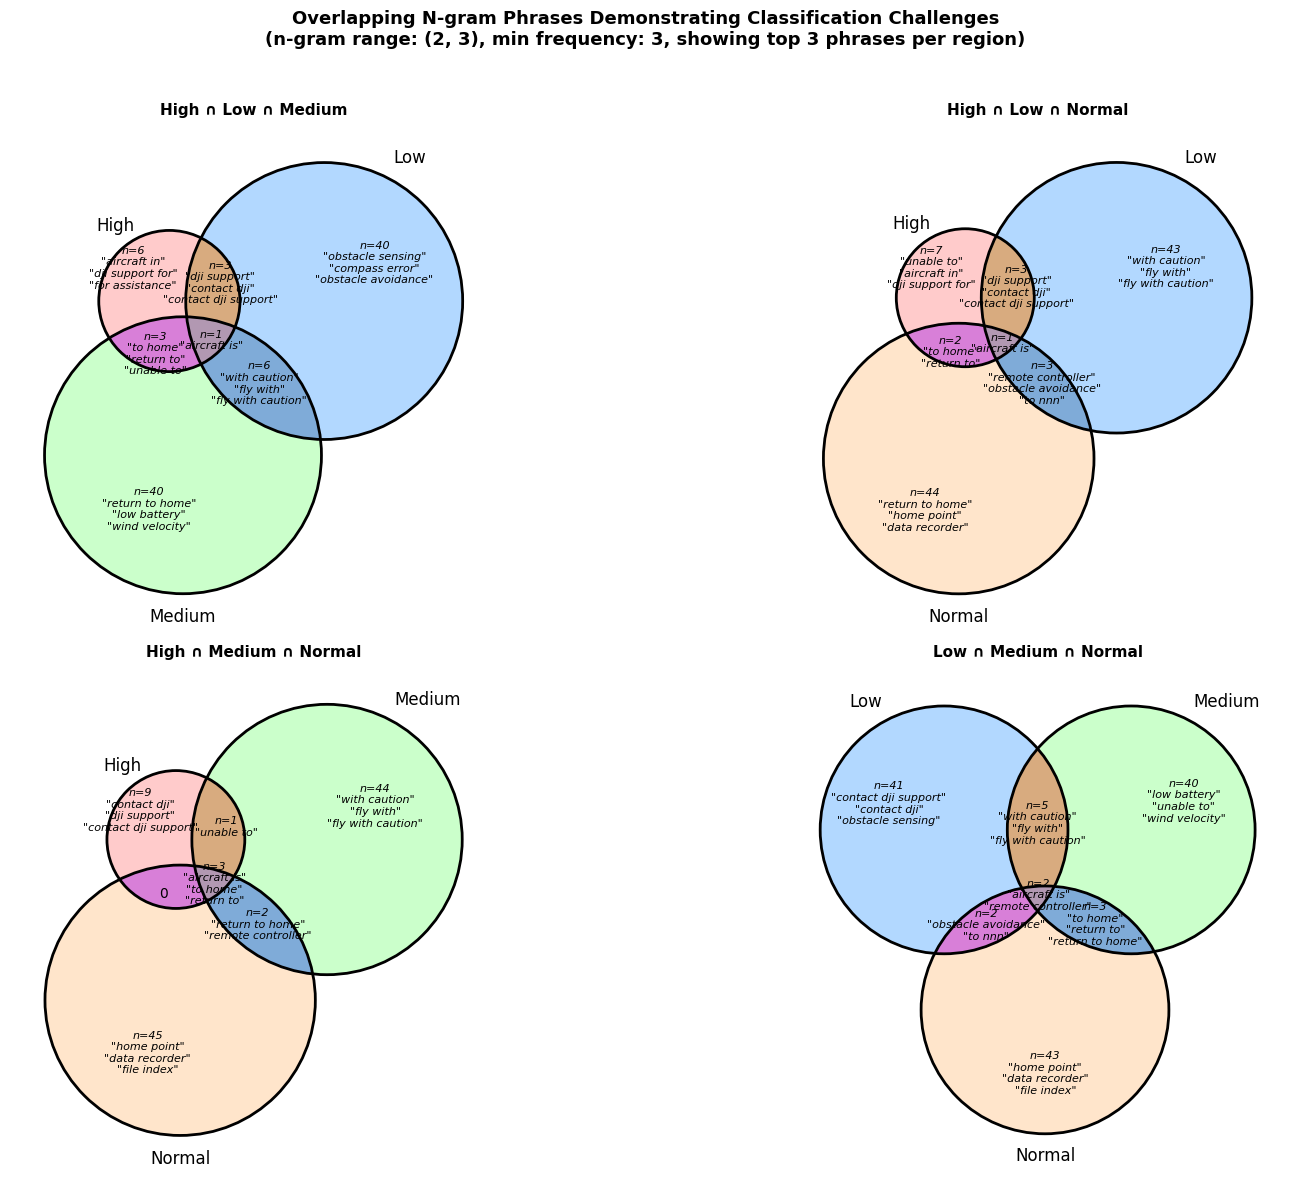

In [12]:

# Usage example
if __name__ == "__main__":
    # Adjust these parameters as needed
    data_path = os.path.join('severity', 'unique')  # Change to your CSV file path
    output_path = 'venn_diagram_with_phrases.png'
    
    # Parameters
    n_range = (2, 3)           # Extract 2-grams and 3-grams
    min_freq = 3               # Minimum frequency for n-gram to be included
    top_n = 50                 # Top N n-grams per class to consider
    max_phrases_per_region = 3 # Show top 3 phrases in each Venn region
    
    class_ngrams, class_freq = create_venn_with_phrases(
        data_path=data_path,
        output_path=output_path,
        n_range=n_range,
        min_freq=min_freq,
        top_n=top_n,
        max_phrases_per_region=max_phrases_per_region,
        figsize=(18, 12),
        dpi=300
    )
    
    plt.show()